# Cluster Analysis
## Descrição
### Introdução
Este *notebook* reproduz procedimento de análise de *clusters* adotado por (Zhang, Zhu, Shen. 2018) [1]. As $N$ observações são particionadas em $K$ *clusters* utilizando algoritmo $K$-Means, utilizando $K$-Means++ como método de determinação preliminar dos centróides. Visto que o algoritmo não garante de convergência para mínimo global, os autores repetiram a análise **200 vezes** e escolheram o que possui **menor distância quadrática entre *clusters***.

O processo previamente mencionado é repetido para diferentes valores de $K$. O número óptimo de $K$ é determinado pela métrica de Xie-Beni, considerando que o número óptimo de $K$ é aquele que minimiza a métrica.


### Expectativas
É esperado que a análise de *clusters*, apesar de ser realizada somente no domínio do tempo, apresente tendência de aglomeração espacial..


### Referências
[1] Zhang, Z., Zhu, G., & Shen, Y. (2018). Data clustering analysis of early reflections in small room. *The Journal of the Acoustical Society of America, 144*(4), EL328–EL332. [https://doi.org/10.1121/1.5065073](https://doi.org/10.1121/1.5065073)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
from sklearn import cluster
import yk_funcs as ykk

## Importando dataset processado
- `Eer` representa envelope de reflexões iniciais de uma sala, com tamanho $M\times T$, em que $M$ é o número de medições e $T$ representa a janela temporal de observação do fenômeno;
- `fs` é a frequência de amostragem ($f_\mathrm s$), nesse contexto, $f_\mathrm s$ é dado em Hz;
- `room_dims` representa as dimensões da sala medida, em metros; e
- `coords` representa a coordenada de cada ponto, em metros.

In [ ]:
with h5.File('SoundFieldControlPlanarDataset_processed.hdf5') as f:
    Eer = f['early_reflections'][:] # Envelope of Early Reflections (900,T)
    fs = f.attrs['fs'][()]          # Sampling frequency (Hz)
    room_dims = f['room_dims'][:]   # Room dimensions (m)
    coords = (f['coords'][:]).T         # Microphone array coordinates (900, 3) (m)

## Análise de clusters
### Estimando o número ideal de clusters
A determinação do número ideal de clusters se dá pela análise do índice de validade de cluster Xie-Beni ($k_\mathrm{xb}$):
$$
k_\mathrm{xb} = \frac{\sum_j^K \sum_{X_i \in C_j} ||X_i - m_j ||^2_2}{N\cdot \min_{i,j \neq i} ||m_i - m_j ||^2_2}
$$
- $||\cdot||_2$ representa a norma $\ell_2$;
- $X_i$ é uma observação do fenômeno;
- $C_j$ representa o cluster $j$ e $m_j$ o seu centróide; e 
- $N$ é o número total de observações.

O índice avalia a compactação de cada cluster utilizando a norma $\ell_2$ da diferença entre as observações pertencentes à um cluster e seu respectivo centroide (no numerador), enquanto penaliza clusters demasiadamente separados(denominador). Dessa forma, um $k_\mathrm{xb}$ menor indica um cluster melhor e mais compacto. O número óptimo de clusters $K^*$ é dado por:
$$
K ^* = \min{k_\mathrm{xb}(K)}
$$

Os parâmetros utilizados no $k$-means seguem procedimento adotado pelo *paper* original [1]: os centróides são inicializados pelo algoritmo $k$-means++, realizando o procedimento 200 vezes e armazenando o resultado que apresenta menor norma de diferença quadrática entre observações e centróides.

In [ ]:
K_val = np.arange(2,8+1)
kxb = np.zeros(len(K_val))
print('::: Init')
for idx, n_clusters in enumerate(K_val):
    print(f'- iter {idx}/{len(kxb)-1}: k = {n_clusters}')
    centroids, categories, _ = cluster.k_means(X=Eer, n_clusters=n_clusters,
                                init='k-means++',n_init=200,
                                )
    kxb[idx] = ykk.xie_beni(Eer,centroids,categories)
print('::: Done')

plt.plot(K_val,kxb)
plt.grid()
plt.title('Xie-Beni Score')
plt.ylabel('$k_\\text{xb}$')
plt.xlabel('$k$')

::: Init
- iter 0/6: k = 2


### Resultado final
A análise de $k_\mathrm{xb}$ permitiu determinar um número óptimo de 3 categorias. 

Nota: visto que, para este conjunto de dados, o procedimento apresenta latência risível, optou-se por reexecutar o algoritmo.

In [23]:
centroids, categories, _ = cluster.k_means(X=Eer, n_clusters=K_val[kxb.argmin()],
                            init='k-means++',n_init=200,
                            )


#### Observação espacial do resultado
Como observado no paper original, apesar do $k$-means ser executado no domínio do tempo, verifica-se que o agrupamento também se manifesta do domínio do espaço. 

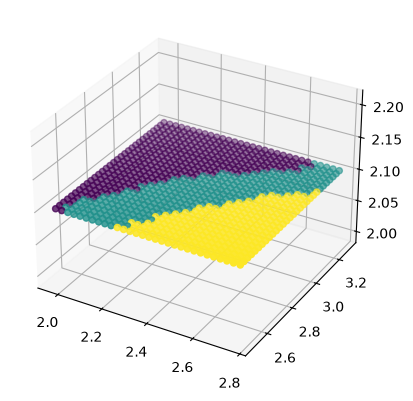

In [27]:
ax = plt.axes(projection='3d')

ax.scatter(coords[:,0],coords[:,1],coords[:,2],c=categories)